In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.utils import shuffle
from scipy.stats import randint
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler, LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, RegressorMixin
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor, early_stopping, Dataset, plot_importance, log_evaluation
import shap
from itertools import product
from scipy.stats import zscore, uniform, randint
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
ain_data = gpd.read_file("../datasets_par_departement/departement-01-ain-original.geojson")
yvelines_data = gpd.read_file("../datasets_par_departement/departement-78-yvelines-original.geojson")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
doubs_voisins = pd.read_csv("../data/data_train_test/doubs_tous_voisins.csv")
ain_voisins = pd.read_csv("../data/data_train_test/ain_tous_voisins.csv")
yvelines_voisins = pd.read_csv("../data/data_train_test/yvelines_tous_voisins.csv")
Naturels = pd.read_csv('../data/firefrance/NATURELSfire.csv')

In [3]:
import numpy as np
class OrdClass(BaseEstimator):
  """
  Helper class that solves ordinal classification (classes that have an order to them eg cold,warm,hot)
  """
  def __init__(self,classifier=None,clf_args=None):
    """
    y needs to be a number that start from 0 and increments by 1
    classifier object needs to be able to return a probability
    """
    self.classifier = classifier
    self.clfs = []
    self.clf_args = clf_args
    self.final_prob = None

  def fit(self,X,y,**fit):
    self.X = X
    self.y = y
    import copy
    no_of_classifiers = np.max(self.y) #since y starts from 0
    self.classes_ = list(range(no_of_classifiers+1))
    if isinstance(self.clf_args,list):
      #for pipelines
      c = self.classifier(self.clf_args)
    elif isinstance(self.clf_args,dict):
      #for normal estimators
       c = self.classifier(**self.clf_args)
    for i in range(no_of_classifiers):
      # make a copy of y because we want to change the values of y
      copy_y = np.copy(self.y)
      # make a binary classification here
      copy_y[copy_y<=i] = 0
      copy_y[copy_y>i] = 1
      classifier = copy.deepcopy(c)
      classifier.fit(self.X,copy_y,**fit)
      self.clfs.append(classifier)
    return self
  def predict_proba(self,test):
    prob_list = []
    final_prob = []
    length = len(self.clfs)
    for clf in self.clfs:
      prob_list.append(clf.predict_proba(test)[:,1])
    for i in range(length+1):
      if i == 0:
        final_prob.append(1-prob_list[i])
      elif i == length:
        final_prob.append(prob_list[i-1])
      else:
        final_prob.append(prob_list[i-1]-prob_list[i])
    answer = np.array(final_prob).transpose()
    self.final_prob= answer
    return answer
  def predict(self,test):
    self.predict_proba(test)
    return np.argmax(self.final_prob,axis=1)
  def score(self,X,y,sample_weight=None):
    from sklearn.metrics import accuracy_score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)

In [4]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')
    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

ain_data = calculer_duree(ain_data, 'date_debut', 'date_fin')
ain_data['centroid'] = ain_data.geometry.centroid
ain_data['centroid_lon'] = ain_data['centroid'].x
ain_data['centroid_lat'] = ain_data['centroid'].y
ain_data['date_debut'] = pd.to_datetime(ain_data['date_debut'], errors='coerce')
ain_data['hour'] = ain_data['date_debut'].dt.hour
ain_data['date'] = pd.to_datetime(ain_data['date'], errors='coerce')
ain_data['month'] = ain_data['date'].dt.month
ain_data['weekday'] = ain_data['date'].dt.weekday
ain_data['duree_minutes'] = pd.to_timedelta(ain_data['duree']).dt.total_seconds() / 60

yvelines_data = calculer_duree(yvelines_data, 'date_debut', 'date_fin')
yvelines_data['centroid'] = yvelines_data.geometry.centroid
yvelines_data['centroid_lon'] = yvelines_data['centroid'].x
yvelines_data['centroid_lat'] = yvelines_data['centroid'].y
yvelines_data['date_debut'] = pd.to_datetime(yvelines_data['date_debut'], errors='coerce')
yvelines_data['hour'] = yvelines_data['date_debut'].dt.hour
yvelines_data['date'] = pd.to_datetime(yvelines_data['date'], errors='coerce')
yvelines_data['month'] = yvelines_data['date'].dt.month
yvelines_data['weekday'] = yvelines_data['date'].dt.weekday
yvelines_data['duree_minutes'] = pd.to_timedelta(yvelines_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [5]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [6]:
all_data = pd.concat([doubs_data, ain_data, yvelines_data], ignore_index=True)

In [7]:
all_data = all_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(all_data)
all_data.dropna(axis=1, thresh=threshold, inplace=True)

all_data.dropna(inplace=True)

In [8]:
cols_to_drop = [
    'raison_sortie', 'label', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'scale0', 'distance', 'saison'
]

all_data = all_data.drop(columns=[col for col in cols_to_drop if col in all_data.columns])

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -422.394899   601.022313  39.349242  58.707707  0.021522   
1   2.1  -447.980329   626.607743  39.085693  57.820369  0.064691   
2   2.2  -473.565759   652.193173  39.085693  57.820369  0.064691   
3   2.3  -499.151189   677.778604  37.802695  57.667296  0.069636   
4   2.4  -524.736620   703.364034  37.802695  57.667296  0.069636   
5   2.5  -550.322050   728.949464  38.641727  58.018904  0.058256   
6   2.6  -575.907480   754.534894  40.401395  59.078463  0.023546   
7   2.7  -601.492911   780.120325  40.401395  59.078463  0.023546   
8   2.8  -627.078341   805.705755  40.401395  59.078463  0.023546   
9   2.9  -652.663771   831.291185  40.401395  59.078463  0.023546   
10  3.0  -678.249201   856.876616  38.979651  58.074081  0.056464   
11  3.1  -703.834632   882.462046  39.778932  58.211628  0.084819   
12  3.2  -729.420062   908.047476  40.393201  64.665954  0.079663   
13  3.3  -755.005492   933.632906 

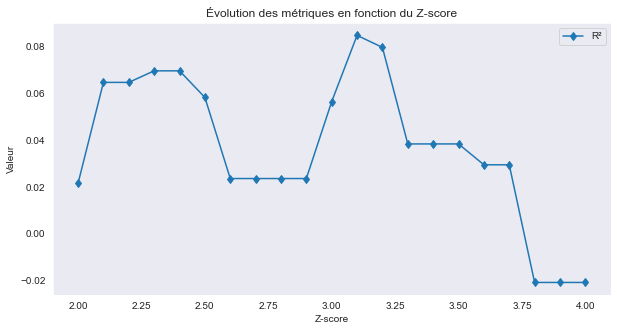

In [9]:
df = all_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

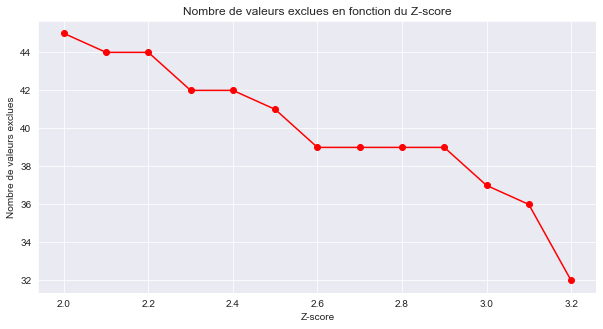

In [10]:
df = all_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -422.394899   601.022313  39.349242  58.707707  0.021522   
1   2.1  -447.980329   626.607743  39.085693  57.820369  0.064691   
2   2.2  -473.565759   652.193173  39.085693  57.820369  0.064691   
3   2.3  -499.151189   677.778604  37.802695  57.667296  0.069636   
4   2.4  -524.736620   703.364034  37.802695  57.667296  0.069636   
5   2.5  -550.322050   728.949464  38.641727  58.018904  0.058256   
6   2.6  -575.907480   754.534894  40.401395  59.078463  0.023546   
7   2.7  -601.492911   780.120325  40.401395  59.078463  0.023546   
8   2.8  -627.078341   805.705755  40.401395  59.078463  0.023546   
9   2.9  -652.663771   831.291185  40.401395  59.078463  0.023546   
10  3.0  -678.249201   856.876616  38.979651  58.074081  0.056464   
11  3.1  -703.834632   882.462046  39.778932  58.211628  0.084819   
12  3.2  -729.420062   908.047476  40.393201  64.665954  0.079663   
13  3.3  -755.005492   933.632906 

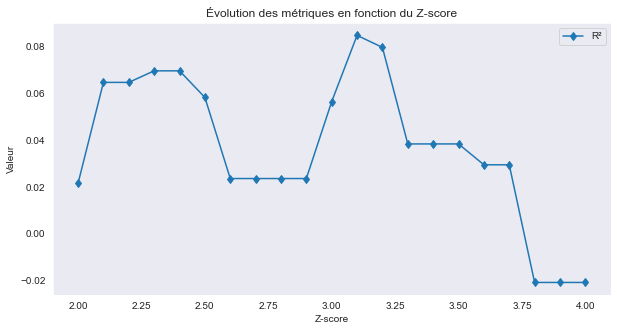

In [11]:
df = all_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

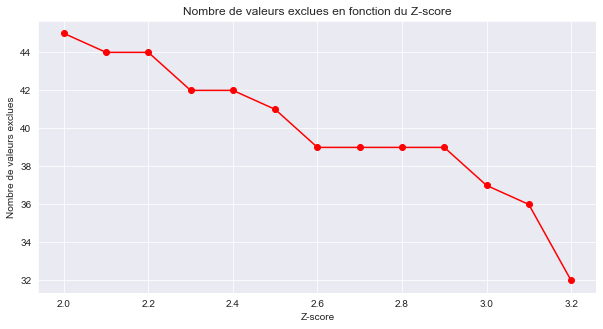

In [12]:
df = all_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

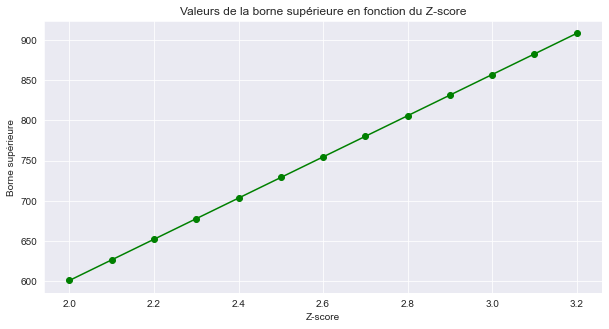

In [13]:
df = all_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [14]:
all_data['z_score'] = np.abs(zscore(all_data['duree_minutes']))

all_data_filtered = all_data[all_data['z_score'] <= 3.1].drop(columns=['z_score'])

values_removed = len(all_data) - len(all_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(all_data) * 100:.2f}%")

Nombre de valeurs supprimées : 36
Pourcentage des données supprimées : 0.47%


In [15]:
all_data_filtered['z_score'] = zscore(all_data_filtered['duree_minutes'])

threshold = 2.9

excluded_values = all_data_filtered[(all_data_filtered['z_score'] > threshold) | (all_data_filtered['z_score'] < -threshold)]

num_excluded = excluded_values.shape[0]

lower_limit = -threshold
upper_limit = threshold

print(f"Nombre de valeurs exclues : {num_excluded}")
print(f"Seuils de z-score : {lower_limit} et {upper_limit}")

Nombre de valeurs exclues : 162
Seuils de z-score : -2.9 et 2.9


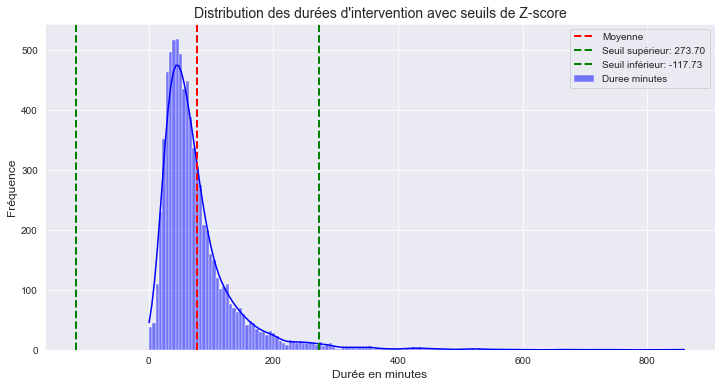

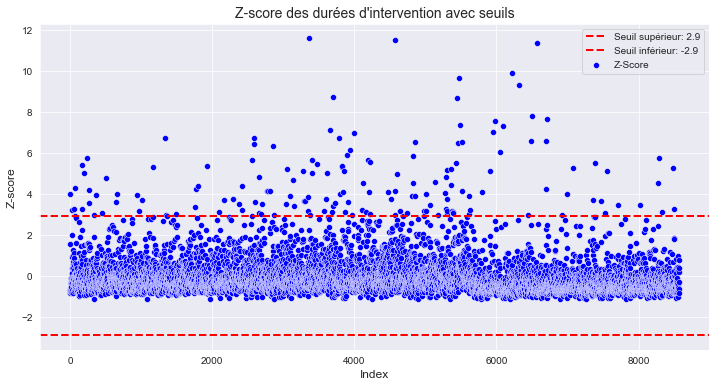

Valeur limite pour le seuil supérieur (z-score = 2.9): 273.70
Valeur limite pour le seuil inférieur (z-score = -2.9): -117.73


In [16]:
mean_duree = all_data_filtered['duree_minutes'].mean()
std_duree = all_data_filtered['duree_minutes'].std()

upper_limit_value = mean_duree + threshold * std_duree
lower_limit_value = mean_duree - threshold * std_duree

plt.figure(figsize=(12, 6))

sns.histplot(all_data_filtered['duree_minutes'], kde=True, color='blue', label='Duree minutes')
plt.axvline(mean_duree, color='red', linestyle='dashed', linewidth=2, label='Moyenne')
plt.axvline(upper_limit_value, color='green', linestyle='dashed', linewidth=2, label=f'Seuil supérieur: {upper_limit_value:.2f}')
plt.axvline(lower_limit_value, color='green', linestyle='dashed', linewidth=2, label=f'Seuil inférieur: {lower_limit_value:.2f}')

plt.title('Distribution des durées d\'intervention avec seuils de Z-score', fontsize=14)
plt.xlabel('Durée en minutes', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend()

plt.show()

plt.figure(figsize=(12, 6))

sns.scatterplot(x=all_data_filtered.index, y=all_data_filtered['z_score'], color='blue', label='Z-Score')

plt.axhline(y=threshold, color='red', linestyle='dashed', linewidth=2, label=f'Seuil supérieur: {threshold}')
plt.axhline(y=-threshold, color='red', linestyle='dashed', linewidth=2, label=f'Seuil inférieur: {-threshold}')

plt.title('Z-score des durées d\'intervention avec seuils', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Z-score', fontsize=12)
plt.legend()

plt.show()

print(f"Valeur limite pour le seuil supérieur (z-score = {threshold}): {upper_limit_value:.2f}")
print(f"Valeur limite pour le seuil inférieur (z-score = {-threshold}): {lower_limit_value:.2f}")

In [17]:
all_data_final = all_data_filtered[(all_data_filtered['z_score'] <= threshold) & (all_data_filtered['z_score'] >= -threshold)]

In [18]:
duplicates = all_data_final.duplicated()

nb_duplicates = duplicates.sum()

print(f"Nombre de lignes dupliquées : {nb_duplicates}")

if nb_duplicates > 0:
    display(all_data_final[duplicates])

Nombre de lignes dupliquées : 0


In [19]:
all_data_final["pop_x_route"] = all_data_final["population"] * (all_data_final["motorway"] + all_data_final["primary"] + all_data_final["secondary"] + all_data_final["tertiary"])

all_data_final["NDVI_NDMI"] = all_data_final["NDVI"] * all_data_final["NDMI"]
all_data_final["NDWI_NDSI"] = all_data_final["NDWI"] * all_data_final["NDSI"]

all_data_final["elev_x_foret"] = all_data_final["elevation"] * all_data_final["foret_encoder"]

all_data_final["log_population"] = np.log1p(all_data_final["population"])
all_data_final["sqrt_elevation"] = np.sqrt(all_data_final["elevation"])


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [20]:
print(all_data_final.isna().sum())

hex_id            0
year              0
date              0
departement       0
duree_minutes     0
                 ..
NDVI_NDMI         0
NDWI_NDSI         0
elev_x_foret      0
log_population    0
sqrt_elevation    0
Length: 62, dtype: int64


In [21]:
all_data_final.head()

,hex_id,year,date,departement,duree_minutes,geometry,centroid,centroid_lon,centroid_lat,hour,...,built,bare,snow,z_score,pop_x_route,NDVI_NDMI,NDWI_NDSI,elev_x_foret,log_population,sqrt_elevation
1,871f82d61ffffff,2014.0,2014-10-03,departement-25-doubs,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",POINT (5.80760 47.26166),5.807597,47.261659,19,...,6.345595,0.0,0.0,-0.836524,2.110985,0.036898,0.350821,0.000000,0.693147,10.010617
2,871f82d61ffffff,2014.0,2014-10-04,departement-25-doubs,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",POINT (5.80760 47.26166),5.807597,47.261659,19,...,6.345595,0.0,0.0,-0.648577,2.110985,0.036898,0.350821,0.000000,0.693147,10.010617
3,871f82d4dffffff,2014.0,2014-10-04,departement-25-doubs,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",POINT (5.89468 47.21782),5.894684,47.217820,20,...,10.204597,0.0,0.0,-0.683647,1958.069441,0.101529,0.381016,450.466232,6.300785,9.491746
4,871f82700ffffff,2014.0,2014-10-05,departement-25-doubs,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",POINT (6.31905 46.75590),6.319047,46.755896,12,...,11.164254,0.0,0.0,-0.762432,474.865276,0.173939,0.380367,0.000000,4.882803,26.297684
5,871f82843ffffff,2014.0,2014-11-02,departement-25-doubs,182.050000,"POLYGON ((6.33190 47.38928, 6.33379 47.37729, ...",POINT (6.34859 47.38524),6.348594,47.385244,18,...,2.953746,0.0,0.0,1.542080,1.194126,0.109603,0.401785,0.000000,0.693172,15.858188


In [22]:
all_data_final.columns

Index(['hex_id', 'year', 'date', 'departement', 'duree_minutes', 'geometry',
       'centroid', 'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'z_score', 'pop_x_route', 'NDVI_NDMI',
       'NDWI_NDSI', 'elev_x_foret', 'log_population', 'sqrt_elevation'],
      dtype='object')

In [23]:
cols_to_exclude = [
    'hex_id', 'geometry', 'centroid', 'hour', 'date', 'z_score',
    'departement', 'duree_minutes'
]

cols_to_avg = [col for col in all_data_final.columns if col not in cols_to_exclude]

data_sum = (
    all_data_final
    .groupby(['departement', 'date'], as_index=False)
    .agg({**{col: 'mean' for col in cols_to_avg}, 'duree_minutes': 'sum'})
    .rename(columns={'duree_minutes': 'duree_jour'})
)

In [24]:
data_sum.columns

Index(['departement', 'date', 'year', 'centroid_lon', 'centroid_lat', 'month',
       'weekday', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'pop_x_route',
       'NDVI_NDMI', 'NDWI_NDSI', 'elev_x_foret', 'log_population',
       'sqrt_elevation', 'duree_jour'],
      dtype='object')

In [30]:
data_sum_shuffled = shuffle(data_sum, random_state=42)

n_total = len(data_sum_shuffled)
n_train = int(0.7 * n_total)
n_valid = int(0.15 * n_total)
n_test = n_total - n_train - n_valid

esg_train = data_sum_shuffled.iloc[:n_train]
esg_valid = data_sum_shuffled.iloc[n_train:n_train + n_valid]
esg_test  = data_sum_shuffled.iloc[n_train + n_valid:]

In [31]:
esg_train = esg_train.copy()
esg_train['date'] = pd.to_datetime(esg_train['date'])

esg_train_sorted = esg_train.sort_values(by=['departement', 'date'])

esg_train_sorted['mean_past_duree_dep'] = (
    esg_train_sorted
    .groupby('departement')['duree_jour']
    .apply(lambda x: x.shift(1).expanding().mean())
)
esg_train = esg_train_sorted.sort_index()

esg_valid['date'] = pd.to_datetime(esg_valid['date'])
esg_test['date'] = pd.to_datetime(esg_test['date'])

train_for_ref = esg_train[['departement', 'date', 'duree_jour']].copy()
train_for_ref = train_for_ref.sort_values(by=['departement', 'date'])

def compute_past_mean(row, train_data):
    dept = row['departement']
    date = row['date']
    filtered = train_data[(train_data['departement'] == dept) & (train_data['date'] < date)]
    if not filtered.empty:
        return filtered['duree_jour'].mean()
    else:
        return np.nan

esg_valid['mean_past_duree_dep'] = esg_valid.apply(lambda row: compute_past_mean(row, train_for_ref), axis=1)
esg_test['mean_past_duree_dep'] = esg_test.apply(lambda row: compute_past_mean(row, train_for_ref), axis=1)

esg_train['mean_past_duree_dep'] = esg_train['mean_past_duree_dep'].fillna(0)
esg_valid['mean_past_duree_dep'] = esg_valid['mean_past_duree_dep'].fillna(0)
esg_test['mean_past_duree_dep'] = esg_test['mean_past_duree_dep'].fillna(0)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [32]:
for df in [esg_train, esg_valid, esg_test]:
    if 'weekday' not in df.columns:
        df['weekday'] = df['date'].dt.weekday

mean_duree_dep = esg_train.groupby('departement')['duree_jour'].mean().reset_index()
mean_duree_dep.rename(columns={'duree_jour': 'mean_dep_duree'}, inplace=True)

mean_duree_weekday = esg_train.groupby('weekday')['duree_jour'].mean().reset_index()
mean_duree_weekday.rename(columns={'duree_jour': 'mean_weekday_duree'}, inplace=True)

std_duree_dep = esg_train.groupby('departement')['duree_jour'].std().reset_index()
std_duree_dep.rename(columns={'duree_jour': 'std_dep_duree'}, inplace=True)

threshold = 400
freq_long_days = (
    esg_train.assign(is_long=esg_train['duree_jour'] > threshold)
    .groupby('departement')['is_long'].mean()
    .reset_index()
    .rename(columns={'is_long': 'freq_long_duree_dep'})
)

for name, df in zip(['train', 'valid', 'test'], [esg_train, esg_valid, esg_test]):
    df = df.merge(mean_duree_dep, on='departement', how='left')
    df = df.merge(std_duree_dep, on='departement', how='left')
    df = df.merge(freq_long_days, on='departement', how='left')
    df = df.merge(mean_duree_weekday, on='weekday', how='left')

    if name == 'train':
        esg_train = df
    elif name == 'valid':
        esg_valid = df
    else:
        esg_test = df

In [33]:
esg_test.columns

Index(['departement', 'date', 'year', 'centroid_lon', 'centroid_lat', 'month',
       'weekday', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'pop_x_route',
       'NDVI_NDMI', 'NDWI_NDSI', 'elev_x_foret', 'log_population',
       'sqrt_elevation', 'duree_jour', 'FL_CCR_CCF', 'nb_eng_CC', 'IN', 'coef',
       'mean_past_duree_dep', 'mean_dep_duree', 'std_dep_duree',
       'freq_long_duree_dep', 'mean_weekday_duree'],
      dtype='object')

In [34]:
esg_train.columns

Index(['departement', 'date', 'year', 'centroid_lon', 'centroid_lat', 'month',
       'weekday', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'pop_x_route',
       'NDVI_NDMI', 'NDWI_NDSI', 'elev_x_foret', 'log_population',
       'sqrt_elevation', 'duree_jour', 'FL_CCR_CCF', 'nb_eng_CC', 'IN', 'coef',
       'mean_past_duree_dep', 'mean_dep_duree', 'std_dep_duree',
       'freq_long_duree_dep', 'mean_weekday_duree'],
      dtype='object')

In [35]:
target = 'duree_jour'

features = [col for col in esg_train.columns if col not in ['duree_jour', 'date', 'departement']]

train_pool = Pool(data=esg_train[features], label=esg_train[target])
valid_pool = Pool(data=esg_valid[features], label=esg_valid[target])
test_pool  = Pool(data=esg_test[features],  label=esg_test[target])

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    early_stopping_rounds=10,
    verbose=100,
    random_state=42
)

model.fit(train_pool, eval_set=valid_pool)

y_valid_pred = model.predict(esg_valid[features])
y_test_pred  = model.predict(esg_test[features])

r2_valid = r2_score(esg_valid[target], y_valid_pred)
r2_test  = r2_score(esg_test[target], y_test_pred)

rmse_valid = np.sqrt(mean_squared_error(esg_valid[target], y_valid_pred))
rmse_test  = np.sqrt(mean_squared_error(esg_test[target], y_test_pred))

print(f"R² (valid) : {r2_valid:.4f}")
print(f"R² (test)  : {r2_test:.4f}")
print(f"RMSE (valid) : {rmse_valid:.2f}")
print(f"RMSE (test)  : {rmse_test:.2f}")

0:	learn: 222.8648003	test: 209.4044541	best: 209.4044541 (0)	total: 73.3ms	remaining: 1m 13s
100:	learn: 97.7179520	test: 99.2436082	best: 99.2436082 (100)	total: 1.38s	remaining: 12.3s
200:	learn: 74.3056134	test: 81.8574924	best: 81.8574924 (200)	total: 2.8s	remaining: 11.1s
300:	learn: 61.1880321	test: 72.6366652	best: 72.6366652 (300)	total: 3.67s	remaining: 8.52s
400:	learn: 52.2720650	test: 66.2122431	best: 66.2122431 (400)	total: 4.59s	remaining: 6.86s
500:	learn: 45.7909490	test: 61.7462507	best: 61.7462507 (500)	total: 5.39s	remaining: 5.37s
600:	learn: 41.2542352	test: 58.6735394	best: 58.6735394 (600)	total: 6.23s	remaining: 4.14s
700:	learn: 37.3940757	test: 55.9727150	best: 55.9727150 (700)	total: 7.73s	remaining: 3.3s
800:	learn: 33.9266930	test: 53.3843376	best: 53.3843376 (800)	total: 9.16s	remaining: 2.27s
900:	learn: 31.1731214	test: 51.4499018	best: 51.4499018 (900)	total: 10.4s	remaining: 1.14s
999:	learn: 29.1247613	test: 50.1375391	best: 50.1375391 (999)	total: 1

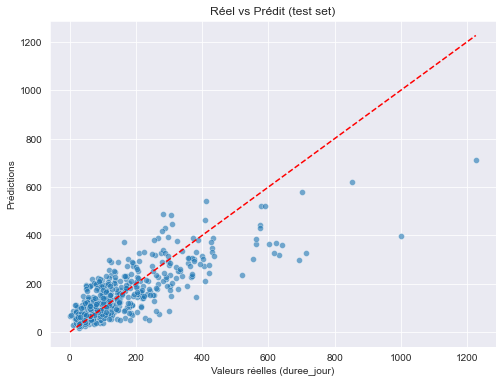

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=esg_test[target], y=y_test_pred, alpha=0.6)
plt.plot([esg_test[target].min(), esg_test[target].max()],
         [esg_test[target].min(), esg_test[target].max()],
         '--', color='red')
plt.xlabel("Valeurs réelles (duree_jour)")
plt.ylabel("Prédictions")
plt.title("Réel vs Prédit (test set)")
plt.grid(True)
plt.show()

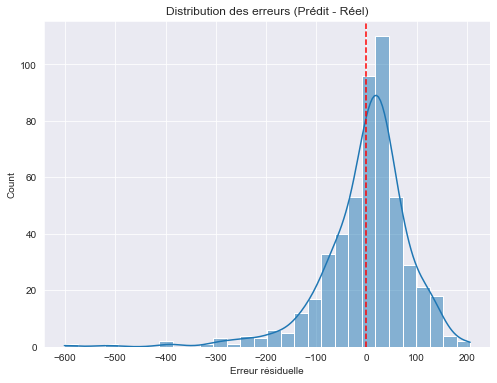

In [32]:
residuals = y_test_pred - esg_test[target]

plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Erreur résiduelle")
plt.title("Distribution des erreurs (Prédit - Réel)")
plt.grid(True)
plt.show()

Glyph 128269 missing from current font.
Glyph 128269 missing from current font.


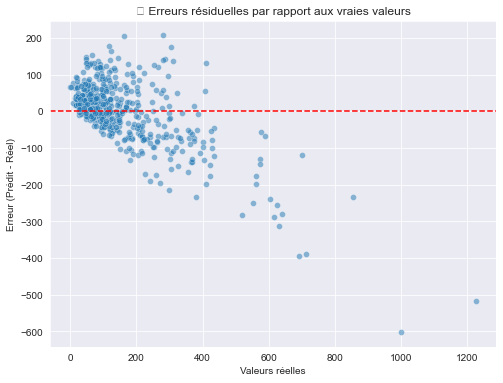

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=esg_test[target], y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Erreur (Prédit - Réel)")
plt.title("🔍 Erreurs résiduelles par rapport aux vraies valeurs")
plt.grid(True)
plt.show()

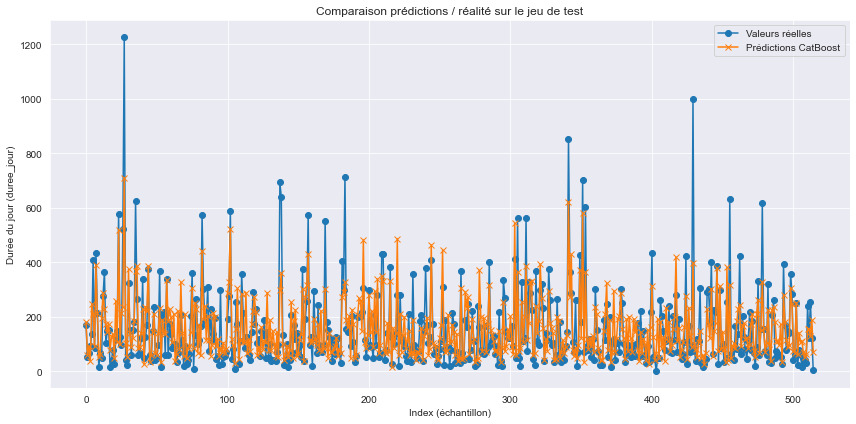

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(esg_test[target].values, label='Valeurs réelles', marker='o')
plt.plot(y_test_pred, label='Prédictions CatBoost', marker='x')
plt.title("Comparaison prédictions / réalité sur le jeu de test")
plt.xlabel("Index (échantillon)")
plt.ylabel("Durée du jour (duree_jour)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
le = LabelEncoder()
for df in [esg_train, esg_valid, esg_test]:
    df['departement_encoded'] = le.fit_transform(df['departement'])

X_train = esg_train.drop(columns=['duree_jour', 'date', 'departement'])
y_train = esg_train['duree_jour']
X_valid = esg_valid.drop(columns=['duree_jour', 'date', 'departement'])
y_valid = esg_valid['duree_jour']
X_test = esg_test.drop(columns=['duree_jour', 'date', 'departement'])
y_test = esg_test['duree_jour']

def clean_column_names(df):
    return df.rename(columns=lambda x: x.encode('ascii', 'ignore').decode('ascii').replace(',', '').replace(' ', '_'))

X_train_clean = clean_column_names(X_train)
X_valid_clean = clean_column_names(X_valid)
X_test_clean = clean_column_names(X_test)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42),
    'CatBoost': CatBoostRegressor(n_estimators=100, random_state=42, verbose=0)
}

results = []

for name, model in models.items():
    print(f"🔍 Entraînement du modèle : {name}")

    if name == 'LightGBM':
        model.fit(X_train_clean, y_train)
        y_val_pred = model.predict(X_valid_clean)
        y_test_pred = model.predict(X_test_clean)
    else:
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_valid)
        y_test_pred = model.predict(X_test)

    r2_val = r2_score(y_valid, y_val_pred)
    rmse_val = mean_squared_error(y_valid, y_val_pred, squared=False)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

    results.append({
        'Modèle': name,
        'R2 (valid)': round(r2_val, 4),
        'RMSE (valid)': round(rmse_val, 2),
        'R2 (test)': round(r2_test, 4),
        'RMSE (test)': round(rmse_test, 2),
    })

results_df = pd.DataFrame(results).sort_values('R2 (valid)', ascending=False)
print(results_df)

🔍 Entraînement du modèle : LinearRegression
🔍 Entraînement du modèle : RandomForest
🔍 Entraînement du modèle : XGBoost
🔍 Entraînement du modèle : LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10305
[LightGBM] [Info] Number of data points in the train set: 2399, number of used features: 56
[LightGBM] [Info] Start training from score 154.118918
🔍 Entraînement du modèle : CatBoost
             Modèle  R2 (valid)  RMSE (valid)  R2 (test)  RMSE (test)
3          LightGBM      0.5955         93.77     0.6615        85.41
4          CatBoost      0.5902         94.38     0.6620        85.34
1      RandomForest      0.5130        102.90     0.5316       100.47
2           XGBoost      0.5110        103.11     0.6109        91.57
0  LinearRegression      0.0335        144.95     0

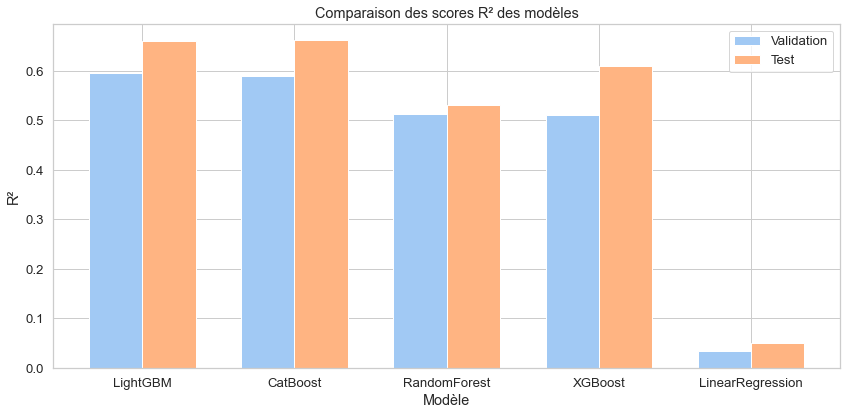

In [36]:
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(len(results_df))

plt.bar(index, results_df['R2 (valid)'], bar_width, label='Validation')
plt.bar(index + bar_width, results_df['R2 (test)'], bar_width, label='Test')

plt.xlabel('Modèle')
plt.ylabel('R²')
plt.title("Comparaison des scores R² des modèles")
plt.xticks(index + bar_width / 2, results_df['Modèle'])
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

lgb_model.fit(
    X_train_clean, y_train,
    eval_set=[(X_valid_clean, y_valid)],
    eval_metric='rmse',
    callbacks=[
        early_stopping(stopping_rounds=10),
        log_evaluation(50)
    ]
)

y_valid_pred = lgb_model.predict(X_valid_clean)
y_test_pred = lgb_model.predict(X_test_clean)

r2_valid = r2_score(y_valid, y_valid_pred)
rmse_valid = mean_squared_error(y_valid, y_valid_pred, squared=False)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

print(f"LightGBM avec Early Stopping")
print(f"R² (valid) : {r2_valid:.4f} | RMSE (valid) : {rmse_valid:.2f}")
print(f"R² (test)  : {r2_test:.4f} | RMSE (test)  : {rmse_test:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091779 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10305
[LightGBM] [Info] Number of data points in the train set: 2399, number of used features: 56
[LightGBM] [Info] Start training from score 154.118918
Training until validation scores don't improve for 10 rounds
[50]	valid_0's rmse: 98.5505	valid_0's l2: 9712.2
[100]	valid_0's rmse: 95.4721	valid_0's l2: 9114.92
Early stopping, best iteration is:
[128]	valid_0's rmse: 94.7868	valid_0's l2: 8984.54
LightGBM avec Early Stopping
R² (valid) : 0.5867 | RMSE (valid) : 94.79
R² (test)  : 0.6734 | RMSE (test)  : 83.89


In [38]:
param_grid = {
    'num_leaves': [31, 50],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [1000],
}

lgb = LGBMRegressor(random_state=42)

grid = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid.fit(
    X_train_clean, y_train,
    eval_set=[(X_valid_clean, y_valid)],
    eval_metric='rmse',
    callbacks=[
        early_stopping(stopping_rounds=10),
        log_evaluation(50)
    ]
)

print("Best params:", grid.best_params_)
print(f"Best CV score (R²) : {grid.best_score_:.4f}")

Fitting 3 folds for each of 64 candidates, totalling 192 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006990 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10305
[LightGBM] [Info] Number of data points in the train set: 2399, number of used features: 56
[LightGBM] [Info] Start training from score 154.118918
Training until validation scores don't improve for 10 rounds
[50]	valid_0's rmse: 97.8685	valid_0's l2: 9578.23
[100]	valid_0's rmse: 94.0922	valid_0's l2: 8853.33
[150]	valid_0's rmse: 93.491	valid_0's l2: 8740.57
Early stopping, best iteration is:
[152]	valid_0's rmse: 93.398	valid_0's l2: 8723.18
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 1000, 'num_leaves': 31, 'subsample': 0.8}
Best CV score (R²) : 0.3621


In [39]:
X_full_train = pd.concat([X_train_clean, X_valid_clean], axis=0)
y_full_train = pd.concat([y_train, y_valid], axis=0)

best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.05,
    'max_depth': 10,
    'min_child_samples': 20,
    'n_estimators': 1000,
    'num_leaves': 31,
    'subsample': 0.8,
    'random_state': 42
}

final_model = LGBMRegressor(**best_params)

final_model.fit(
    X_full_train, y_full_train,
    eval_set=[(X_test_clean, y_test)],
    eval_metric='rmse',
    callbacks=[
        early_stopping(stopping_rounds=10),
        log_evaluation(50)
    ]
)

y_test_pred = final_model.predict(X_test_clean)
r2_test = r2_score(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

print("Résultats LightGBM (meilleurs params) sur le test")
print(f"R² (test)  : {r2_test:.4f}")
print(f"RMSE (test): {rmse_test:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10579
[LightGBM] [Info] Number of data points in the train set: 2913, number of used features: 56
[LightGBM] [Info] Start training from score 154.376622
Training until validation scores don't improve for 10 rounds
[50]	valid_0's rmse: 93.4004	valid_0's l2: 8723.64
[100]	valid_0's rmse: 86.67	valid_0's l2: 7511.7
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[150]	valid_0's rmse: 84.9047	valid_0's l2: 7208.81
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

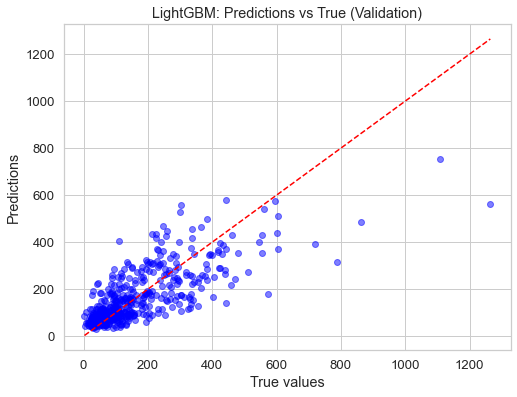

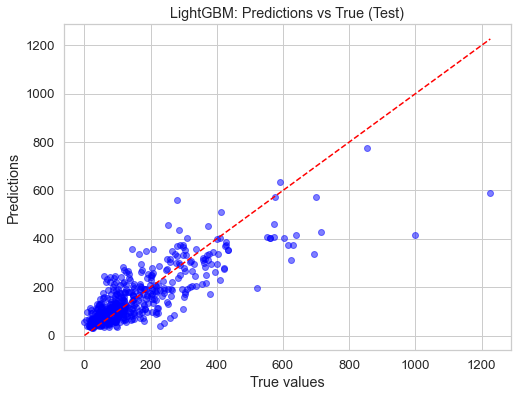

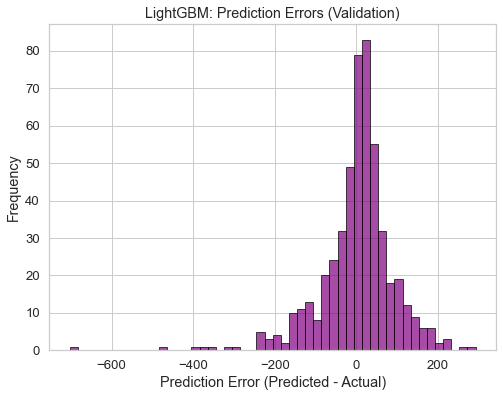

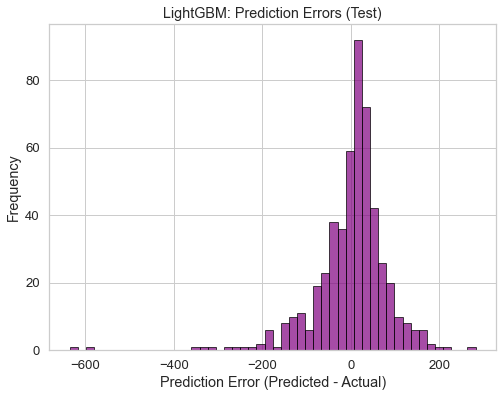

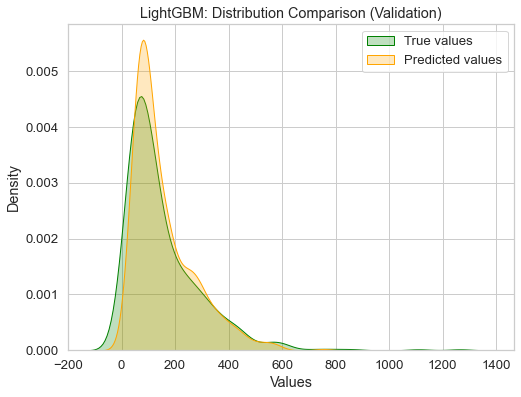

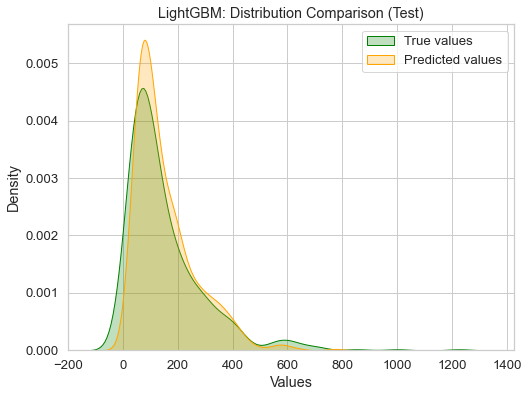

In [40]:
def plot_predictions_vs_true(y_true, y_pred, title='Predictions vs True values'):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, color='blue', alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--')
    plt.title(title)
    plt.xlabel('True values')
    plt.ylabel('Predictions')
    plt.show()

plot_predictions_vs_true(y_valid, y_valid_pred, title='LightGBM: Predictions vs True (Validation)')

plot_predictions_vs_true(y_test, y_test_pred, title='LightGBM: Predictions vs True (Test)')

def plot_prediction_errors(y_true, y_pred, title='Prediction Errors'):
    errors = y_pred - y_true
    plt.figure(figsize=(8, 6))
    plt.hist(errors, bins=50, color='purple', edgecolor='black', alpha=0.7)
    plt.title(title)
    plt.xlabel('Prediction Error (Predicted - Actual)')
    plt.ylabel('Frequency')
    plt.show()

plot_prediction_errors(y_valid, y_valid_pred, title='LightGBM: Prediction Errors (Validation)')

plot_prediction_errors(y_test, y_test_pred, title='LightGBM: Prediction Errors (Test)')

def plot_distribution_comparison(y_true, y_pred, title='Distribution Comparison (True vs Predicted)'):
    plt.figure(figsize=(8, 6))
    sns.kdeplot(y_true, label='True values', color='green', shade=True)
    sns.kdeplot(y_pred, label='Predicted values', color='orange', shade=True)
    plt.title(title)
    plt.xlabel('Values')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

plot_distribution_comparison(y_valid, y_valid_pred, title='LightGBM: Distribution Comparison (Validation)')

plot_distribution_comparison(y_test, y_test_pred, title='LightGBM: Distribution Comparison (Test)')

In [41]:
model_cat_full = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=5,
    l2_leaf_reg=10,
    random_seed=42,
    loss_function='RMSE',
    verbose=200
)

model_cat_full.fit(
    X_full_train, y_full_train,
    eval_set=[(X_test_clean, y_test)],
    early_stopping_rounds=100,
    use_best_model=True
)

y_pred = model_cat_full.predict(X_valid_clean)

mask = np.isfinite(y_valid)
y_valid_clean = y_valid[mask]
y_pred_clean = y_pred[mask]

r2 = r2_score(y_valid_clean, y_pred_clean)
rmse = mean_squared_error(y_valid_clean, y_pred_clean, squared=False)

print(f"R² sur la validation: {r2:.4f}")
print(f"RMSE sur la validation: {rmse:.2f}")

y_test_pred = model_cat_full.predict(X_test_clean)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)

print(f"R² sur le test: {r2_test:.4f}")
print(f"RMSE sur le test: {rmse_test:.2f}")

0:	learn: 151.0002561	test: 145.6001250	best: 145.6001250 (0)	total: 5.77ms	remaining: 8.64s
200:	learn: 93.7341313	test: 93.5661119	best: 93.5661119 (200)	total: 1.63s	remaining: 10.5s
400:	learn: 83.3288071	test: 89.0096874	best: 89.0096874 (400)	total: 2.86s	remaining: 7.84s
600:	learn: 75.1312170	test: 86.0161090	best: 86.0161090 (600)	total: 3.9s	remaining: 5.84s
800:	learn: 70.1721820	test: 85.0148164	best: 85.0148164 (800)	total: 5s	remaining: 4.36s
1000:	learn: 65.4714590	test: 84.5117513	best: 84.4995158 (989)	total: 6.1s	remaining: 3.04s
1200:	learn: 61.0936459	test: 84.3506054	best: 84.2717205 (1111)	total: 7.28s	remaining: 1.81s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 84.27172046
bestIteration = 1111

Shrink model to first 1112 iterations.
R² sur la validation: 0.8203
RMSE sur la validation: 62.50
R² sur le test: 0.6704
RMSE sur le test: 84.27


In [42]:
residuals = y_test - y_test_pred
abs_errors = np.abs(residuals)

In [43]:
error_df = X_test_clean.copy()
error_df['y_true'] = y_test
error_df['y_pred'] = y_test_pred
error_df['residual'] = residuals
error_df['abs_error'] = abs_errors

top_errors = error_df.sort_values(by='abs_error', ascending=False).head(10)
print(top_errors[['y_true', 'y_pred', 'residual', 'abs_error']])

          y_true      y_pred    residual   abs_error
429  1000.533333  437.037699  563.495634  563.495634
27   1226.583333  733.262503  493.320830  493.320830
137   693.000000  316.290534  376.709466  376.709466
183   713.516667  349.415099  364.101568  364.101568
26    520.850000  211.349306  309.500694  309.500694
455   631.883333  323.453242  308.430091  308.430091
220   280.116667  574.795998 -294.679332  294.679332
35    624.000000  355.401202  268.598798  268.598798
138   639.633333  387.280195  252.353139  252.353139
95    299.000000   64.245719  234.754281  234.754281


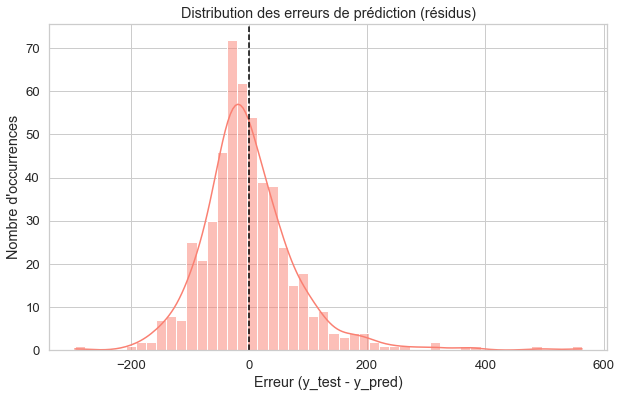

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='salmon')
plt.axvline(0, color='black', linestyle='--')
plt.title("Distribution des erreurs de prédiction (résidus)")
plt.xlabel("Erreur (y_test - y_pred)")
plt.ylabel("Nombre d'occurrences")
plt.show()

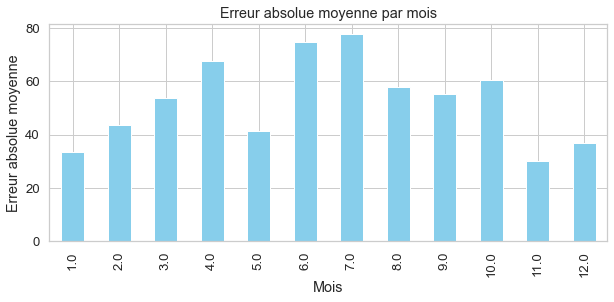

In [45]:
error_df['month'] = X_test_clean['month']

month_error = error_df.groupby('month')['abs_error'].mean()

month_error.plot(kind='bar', color='skyblue', figsize=(10, 4))
plt.title("Erreur absolue moyenne par mois")
plt.ylabel("Erreur absolue moyenne")
plt.xlabel("Mois")
plt.show()

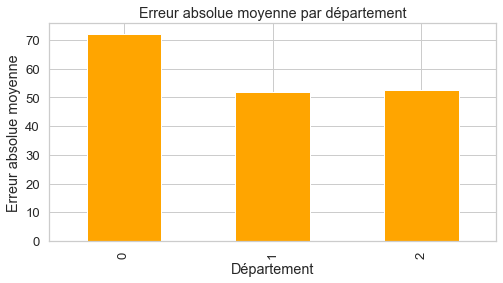

In [46]:
error_df['departement_encoded'] = X_test_clean['departement_encoded']  # si la colonne existe

dept_error = error_df.groupby('departement_encoded')['abs_error'].mean()
dept_error.plot(kind='bar', color='orange', figsize=(8, 4))
plt.title("Erreur absolue moyenne par département")
plt.ylabel("Erreur absolue moyenne")
plt.xlabel("Département")
plt.show()

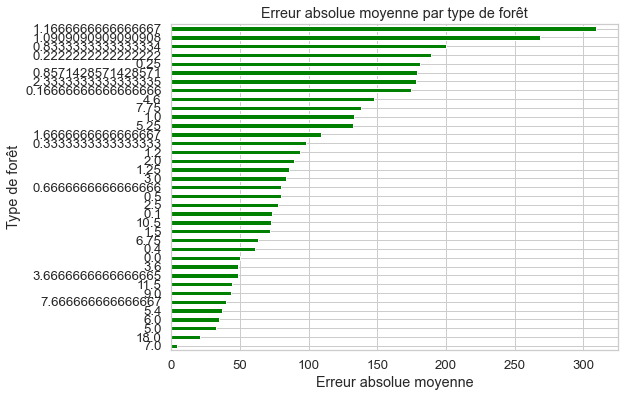

In [47]:
error_df['foret'] = X_test_clean['foret_encoder']

foret_error = error_df.groupby('foret')['abs_error'].mean().sort_values()
foret_error.plot(kind='barh', color='green', figsize=(8, 6))
plt.title("Erreur absolue moyenne par type de forêt")
plt.xlabel("Erreur absolue moyenne")
plt.ylabel("Type de forêt")
plt.show()

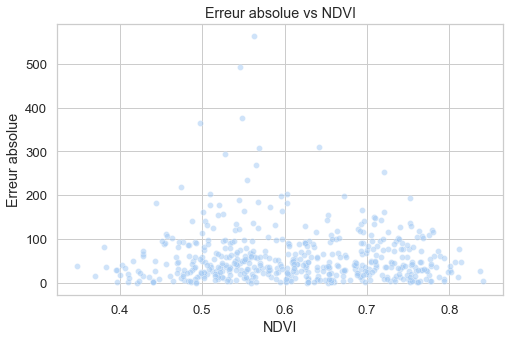

In [48]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_test_clean['NDVI'], y=abs_errors, alpha=0.5)
plt.title("Erreur absolue vs NDVI")
plt.xlabel("NDVI")
plt.ylabel("Erreur absolue")
plt.show()

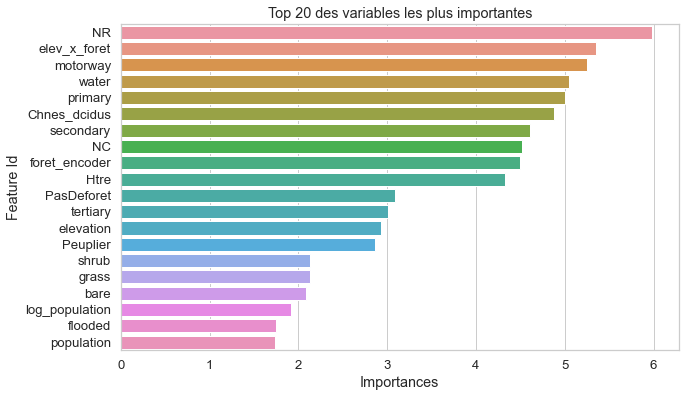

In [49]:
importances = model_cat_full.get_feature_importance(prettified=True)
importances.sort_values(by="Importances", ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(20), x="Importances", y="Feature Id")
plt.title("Top 20 des variables les plus importantes")
plt.show()

In [50]:
importances.tail(20)

,Feature Id,Importances
40,NDSI,0.470877
41,NDMI,0.458553
42,year,0.451702
43,Mlze,0.434029
44,NDVI_NDMI,0.409656
45,departement_encoded,0.406840
46,NDBI,0.369125
47,Pin_laricio_pin_noir,0.334099
48,NDWI,0.274966
49,mean_weekday_duree,0.273740


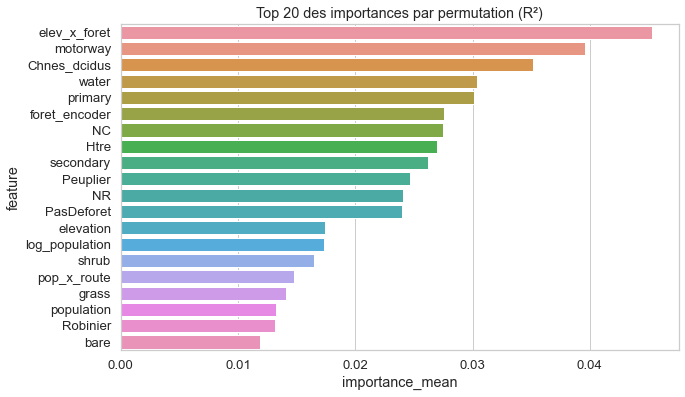

In [51]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_cat_full,
    X_test_clean,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

perm_df = pd.DataFrame({
    'feature': X_test_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df.head(20), x="importance_mean", y="feature")
plt.title("Top 20 des importances par permutation (R²)")
plt.show()

In [52]:
perm_df.tail(20)

,feature,importance_mean,importance_std
6,NDMI,0.001854,0.001151
59,departement_encoded,0.001545,0.000780
53,sqrt_elevation,0.001422,0.001043
54,mean_past_duree_dep,0.000907,0.002425
5,NDVI,0.000861,0.002014
9,NDWI,0.000603,0.000414
57,freq_long_duree_dep,0.000570,0.000711
56,std_dep_duree,0.000340,0.000654
55,mean_dep_duree,0.000201,0.000264
7,NDBI,0.000165,0.000707
